In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
from matplotlib import pyplot as plt

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/train.csv.zip
/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/sample_submission.csv.zip
/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/test.csv.zip


In [2]:
train_path = "/kaggle/input/competitions/ghouls-goblins-and-ghosts-boo/train.csv.zip"
df = pd.read_csv(train_path, index_col="id")

In [3]:
df.head()

,bone_length,rotting_flesh,hair_length,has_soul,color,type
id,,,,,,
0,0.354512,0.350839,0.465761,0.781142,clear,Ghoul
1,0.575560,0.425868,0.531401,0.439899,green,Goblin
2,0.467875,0.354330,0.811616,0.791225,black,Ghoul
4,0.776652,0.508723,0.636766,0.884464,black,Ghoul
5,0.566117,0.875862,0.418594,0.636438,green,Ghost


In [4]:
df.describe()

,bone_length,rotting_flesh,hair_length,has_soul
count,371.000000,371.000000,371.000000,371.000000
mean,0.434160,0.506848,0.529114,0.471392
std,0.132833,0.146358,0.169902,0.176129
min,0.061032,0.095687,0.134600,0.009402
25%,0.340006,0.414812,0.407428,0.348002
50%,0.434891,0.501552,0.538642,0.466372
75%,0.517223,0.603977,0.647244,0.600610
max,0.817001,0.932466,1.000000,0.935721


In [5]:
df.isnull().sum()

bone_length      0
rotting_flesh    0
hair_length      0
has_soul         0
color            0
type             0
dtype: int64

The data is clean, that makes our work easier!

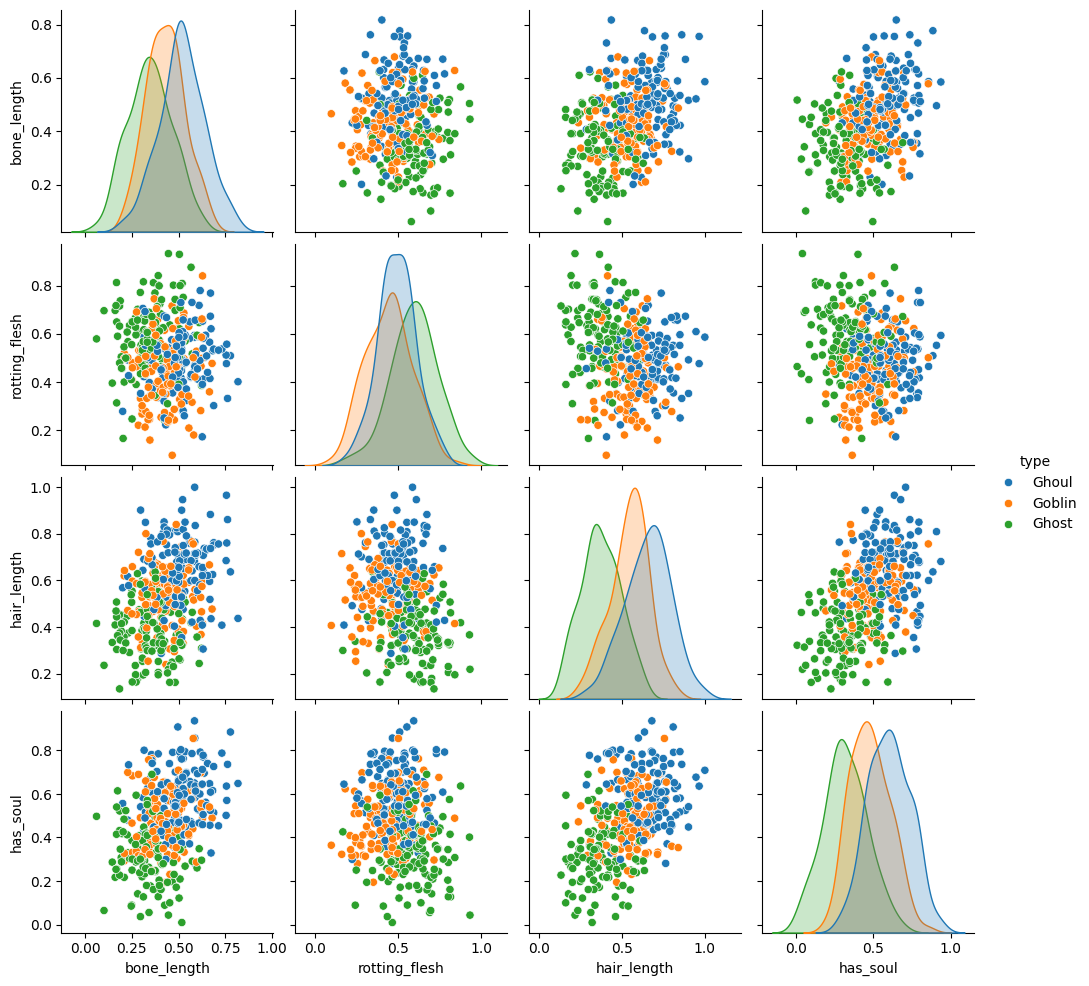

In [6]:
sns.pairplot(df, hue = "type")

<Axes: xlabel='id'>

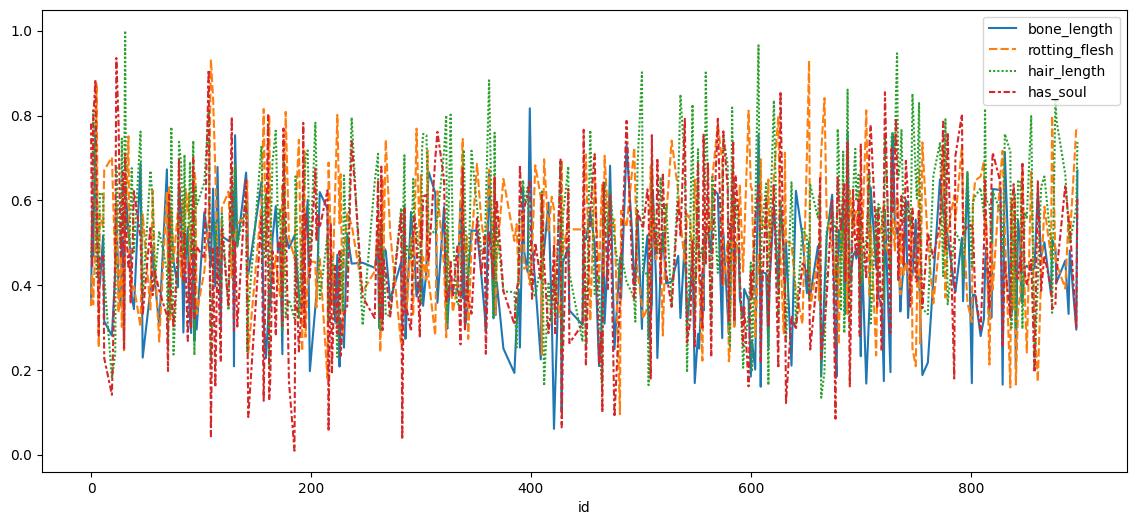

In [7]:
plt.figure(figsize=(14, 6))
sns.lineplot(df)

<Axes: ylabel='Density'>

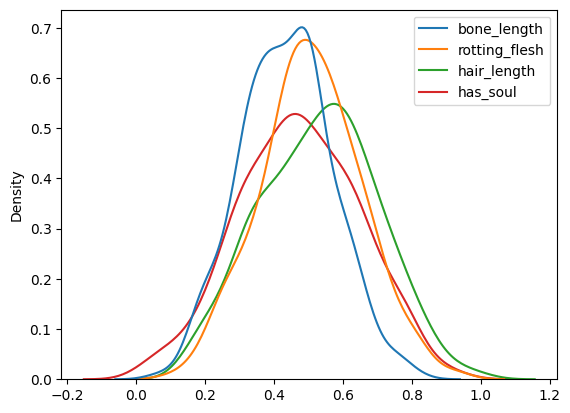

In [8]:
sns.kdeplot(df)

All the features are almost Normally distributed

In [9]:
from sklearn import tree # Decision Tree
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

le = LabelEncoder()
decision_tree_model = tree.DecisionTreeClassifier()

In [10]:
cols = list(df.columns)
cols.pop()
cols

['bone_length', 'rotting_flesh', 'hair_length', 'has_soul', 'color']

In [11]:
df["color"] = le.fit_transform(df["color"])
X = df.loc[:, cols]

In [12]:
y = df.type
y.head()

id
0     Ghoul
1    Goblin
2     Ghoul
4     Ghoul
5     Ghost
Name: type, dtype: object

In [13]:
X_train, y_train, X_test, y_test = train_test_split(X, y, test_size=0.30, random_state=5)

In [14]:
X_train.head()

,bone_length,rotting_flesh,hair_length,has_soul,color
id,,,,,
515,0.227948,0.501056,0.471120,0.698965,5
820,0.626615,0.389805,0.620758,0.712549,5
29,0.500197,0.438418,0.532530,0.665522,3
705,0.167798,0.812293,0.507361,0.414697,3
125,0.504236,0.620758,0.341074,0.348578,0


In [15]:
y_train

,bone_length,rotting_flesh,hair_length,has_soul,color
id,,,,,
115,0.678519,0.476821,0.477152,0.489358,2
300,0.387730,0.659535,0.356108,0.550968,4
632,0.502229,0.504399,0.263549,0.121687,5
143,0.424969,0.240299,0.338678,0.088924,5
594,0.391036,0.506061,0.252296,0.347765,0
...,...,...,...,...,...
427,0.540806,0.323365,0.690605,0.698480,5
222,0.313506,0.616803,0.396482,0.447946,2
180,0.486970,0.511617,0.365142,0.171539,5


In [16]:
# decision_tree_model.fit(X_train, y_train)